# Critical point in electromagnetic Anderson localization in three dimensions

Anderson localization (AL) is a wave interference phenomenon that can suppress wave transport in disordered media. The recent work by Yamilov, Cao, and Skipetrov (https://arxiv.org/abs/2408.04853) demonstrates a clear transition between diffusive and localized regimes for light in 3D. Using Tidy3D, finite-difference time-domain (FDTD), simulations of electromagnetic wave propagation through randomly distributed perfect electric conducting (PEC) spheres, a critical frequency (mobility edge) where this transition occurs has been identified.

In this notebook, we will qualitatively reproduce the results presented in Fig. 1a of the paper for spheres with a radius of 75 nm, exploring two different simulation domain sizes (2λ)³ and (3λ)³. This notebook is contributed by Dr. Alexey Yamilov

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

import tidy3d as td
from tidy3d import web
from tidy3d import SpatialDataArray

td.config.logging_level = "ERROR"

### Define study parameters

We now define global parameters for the simulation

In [2]:
# Free space central wavelength in um and center frequency
wavelength = 0.50
freq0 = td.C_0 / wavelength

# Bandwidth of the excitation pulse in Hz, chosen so that Fourier transform can be computed for f0a frequencies
fwidth = freq0 / 7.0


# Space between PML and slab
space = 1 * wavelength

# Sphere radius in um
sphere_r = 0.075

# Define number of random realizations
nseeds = 30

# Define random seed (to replicate disordered slab, if needed)
seeds = 0 + np.arange(nseeds)

# Grids per wavelength
grids_pw = 20
dt0 = 0.99 * wavelength / (grids_pw * td.C_0 * np.sqrt(3))

# Number of PML layers to use along z direction
npml = 2 * grids_pw

# We use a uniform grid size to speed up the meshing process
dl = wavelength / grids_pw
grid_spec = td.GridSpec.uniform(dl=dl)

# Frequencies to analyse
freqs = freq0 * np.linspace(0.7, 1.4, 2001)

# Define boundary conditions: Periodic in x and y, and PML in z

sys = "PEC"
periodic_bc = td.Boundary(plus=td.Periodic(), minus=td.Periodic())
pml = td.Boundary(plus=td.Absorber(num_layers=npml), minus=td.Absorber(num_layers=npml))
boundary_spec = td.BoundarySpec(x=periodic_bc, y=periodic_bc, z=pml)

# Gaussian source offset; the source peak is at time t = offset/fwidth
offset = 10.0

# Defining spheres material as Perfect Electric Conductor
medium = td.PEC
medium_out = td.Medium(permittivity=1)

The realized volume filling fraction depends on the overlap between spheres, smoothing and discretization, it is computed after simulation is done. Accounting for only sphere overlaps, $ff$ can be found as $ff_{appx}  = 1 - e^{(-ff0)}$

In [3]:
# Nominal volume filling fraction, actual filling fraction is lower due to overlap between spheres
ff0 = 0.95

# Approximate filling fraction
ff_appx = 1 - np.exp(-ff0)

Now we will define a function for generating the random structure as a function of the seed:

In [4]:
def generate_structure(seed, L):
    structures = []

    # Compute number of spheres to place: volume * nominal_density = number of spheres
    num_spheres = int(
        (L + 2 * sphere_r)
        * (L + 2 * sphere_r)
        * (L + 2 * sphere_r)
        * ff0
        / (4 * np.pi / 3 * sphere_r**3)
    )
    np.random.seed(seed)

    # Randomly position spheres
    for i in range(num_spheres):
        position_x = np.random.uniform(-L / 2 - sphere_r, L / 2 + sphere_r)
        position_y = np.random.uniform(-L / 2 - sphere_r, L / 2 + sphere_r)
        position_z = np.random.uniform(-L / 2 - sphere_r, L / 2 + sphere_r)
        radius_i = sphere_r
        name_i = f"sphere_i={i}"
        sphere_i = td.Sphere(
            center=[position_x, position_y, position_z], radius=radius_i
        )
        structure_i = td.Structure(geometry=sphere_i, medium=medium)
        structures.append(structure_i)

    # Define effective medium around the slab
    box1 = td.Box(center=[0, 0, -L / 2 - space], size=[td.inf, td.inf, 2 * space])
    box2 = td.Box(center=[0, 0, L / 2 + space], size=[td.inf, td.inf, 2 * space])
    struct1 = td.Structure(geometry=box1, medium=medium_out)
    structures.append(struct1)
    struct2 = td.Structure(geometry=box2, medium=medium_out)
    structures.append(struct2)

    return structures

Defining a function for creating the simulation object

In [5]:
def make_sim(seed, L, run_time):
    # Defining simulation size
    Lz_tot = space + L + space
    sim_size = [L, L, Lz_tot]

    structures = generate_structure(seed, L)

    # Define incident plane wave
    gaussian = td.GaussianPulse(freq0=freq0, fwidth=fwidth, offset=offset, phase=0)
    source = td.PlaneWave(
        size=(td.inf, td.inf, 0.0),
        center=(0, 0, -Lz_tot / 2.0 + 0.1 * wavelength),
        source_time=gaussian,
        direction="+",
        pol_angle=0,
    )

    # Transmitted flux through the slab
    flux_monitor = td.FluxMonitor(
        center=[0.0, 0.0, L / 2.0 + space / 2.0],
        size=[td.inf, td.inf, 0],
        freqs=freqs,
        name="flux_monitor",
    )

    # Records time-dependent transmitted flux through the slab
    flux_time_monitor = td.FluxTimeMonitor(
        center=[0.0, 0.0, L / 2.0 + space / 2.0],
        size=[td.inf, td.inf, 0],
        name="flux_time_monitor",
    )

    monitors = [flux_monitor, flux_time_monitor]  # ,eps_monitor]

    # Define simulation object
    sim = td.Simulation(
        size=sim_size,
        grid_spec=grid_spec,
        structures=structures,
        sources=[source],
        monitors=monitors,
        run_time=run_time,
        boundary_spec=boundary_spec,
        shutoff=1e-15,
    )

    return sim

In [6]:
# Create a simulation batch for L = 2 wavelengths
sims2 = {}
for seed in seeds:
    sims2["%i" % seed] = make_sim(seed, L=2 * wavelength, run_time=3e-12)

In [7]:
# Create a simulation batch for L = 3 wavelengths
sims3 = {}
for seed in seeds:
    sims3["%i" % seed] = make_sim(seed, L=3 * wavelength, run_time=6e-12)

In [8]:
# Running batch
batch2 = web.Batch(simulations=sims2, verbose=True)
batch_data2 = batch2.run()

Output()

23:21:36 Eastern Standard Time Started working on Batch containing 30 tasks.

23:22:34 Eastern Standard Time Maximum FlexCredit cost: 0.750 for the whole     
                               batch.

                               Use 'Batch.real_cost()' to get the billed        
                               FlexCredit cost after the Batch has completed.

Output()

23:22:47 Eastern Standard Time Batch complete.

Output()

In [9]:
# Running batch
batch3 = web.Batch(simulations=sims3, verbose=True)
batch_data3 = batch3.run()

Output()

23:26:58 Eastern Standard Time Started working on Batch containing 30 tasks.

23:28:59 Eastern Standard Time Maximum FlexCredit cost: 2.208 for the whole     
                               batch.

                               Use 'Batch.real_cost()' to get the billed        
                               FlexCredit cost after the Batch has completed.

Output()

23:29:12 Eastern Standard Time Batch complete.

Output()

Now, we will load the batch data and calculate $\langle \log{(g)} \rangle$

In [10]:
def analyse_g(batch_data, L):
    T_of_f = []

    # Load frequency-resolved transmission for all realizations of disorder
    for seed in seeds:
        sim_data = batch_data["%i" % seed]
        fT = sim_data["flux_monitor"].flux
        T_of_f = np.hstack([T_of_f, fT.values])

    normalized_L = L / wavelength
    normalized_freqs = freqs / freq0

    # Calculate of the ensemble-averaged <log(g)> as a function of frequency
    Lp = normalized_L * wavelength
    ka = 2 * np.pi / wavelength * normalized_freqs.T
    T_of_f_ave = np.exp(
        np.transpose(np.mean(np.log(T_of_f.reshape(int(nseeds), -1)), axis=0))
    )
    logg = np.log(
        np.multiply(T_of_f_ave, ka.flatten() ** 2) * Lp**2 / (2 * np.pi) * 0.80
    )

    return logg

In [11]:
logg2 = analyse_g(batch_data2, 2 * wavelength)
logg3 = analyse_g(batch_data3, 3 * wavelength)

Plotting the data, we observe the curves crossing at the critical point (the mobility edge). To the left/right of the critical point conductance decreases/increases with an increase of the system size L. At the critical point, the conductance is invariant with the system size. This indicates a sharp Anderson transition in the L→∞ limit, see https://arxiv.org/abs/2408.04853 for details.

Smoother data can be obtained by increasing `nseeds`.

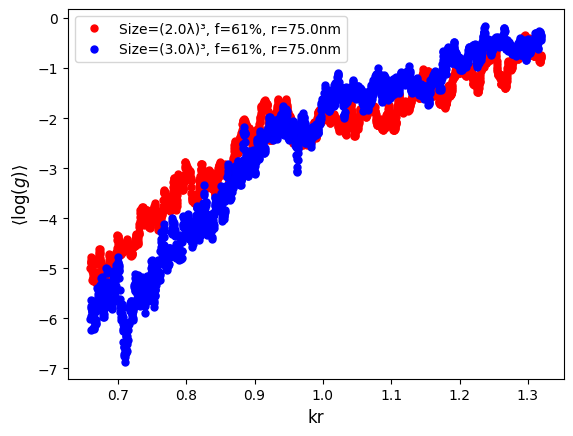

In [12]:
fig, ax = plt.subplots()

normalized_freqs = freqs / freq0
normalized_L2 = 2 * wavelength / wavelength
normalized_L3 = 3 * wavelength / wavelength

ax.plot(
    (2 * np.pi / wavelength * normalized_freqs.T * sphere_r),
    logg2,
    "r.",
    markersize=10,
    linewidth=1,
    label=f"Size=({normalized_L2}λ)³, f={ff_appx*100:.0f}%, r={1000*sphere_r}nm",
)

ax.plot(
    (2 * np.pi / wavelength * normalized_freqs.T * sphere_r),
    logg3,
    "b.",
    markersize=10,
    linewidth=1,
    label=f"Size=({normalized_L3}λ)³, f={ff_appx*100:.0f}%, r={1000*sphere_r}nm",
)

ax.set_xlabel("kr", fontsize=12)
ax.set_ylabel(r"$\langle\log(g)\rangle$", fontsize=12)
ax.legend(fontsize=12, loc="best")

ax.legend()

plt.show()